In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm
from functions import lowess

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = plt.cm.viridis
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')

In [3]:
def classificar_idade(age):
    return 'Young clusters' if age < 8 else 'Old-clusters'

aux = data.copy(deep=True)
aux = aux[aux.q > 0]
aux['age_group'] = aux['age'].apply(classificar_idade)


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins=12)
    axs[i].set_title(age_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
plt.savefig('Figures/hist_mass_ratio_mass.png', bbox_inches='tight', dpi=300)
plt.show()


KeyError: 'age'

In [ ]:
#Compara as distribuições da razão de massa dos dois subconjuntos

young_q = aux[aux.age_group == 'Young clusters']['q']
old_q = aux[aux.age_group == 'Old-clusters']['q']

# Kolmogorov–Smirnov test
ks_stat, ks_p = ks_2samp(young_q, old_q)
print(f"KS test: stat = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')
    
# Mann–Whitney U test    
u_stat, u_p = mannwhitneyu(young_q, old_q, alternative='two-sided')
print(f"Mann–Whitney U test: U = {u_stat:.4f}, p = {u_p:.4f}")

if u_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')

# Anderson–Darling test  
result = anderson_ksamp([young_q, old_q])
print(f"Anderson–Darling test: stat = {result.statistic:.4f}, p = {result.significance_level:.4f}")
if result.significance_level < 5: 
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')



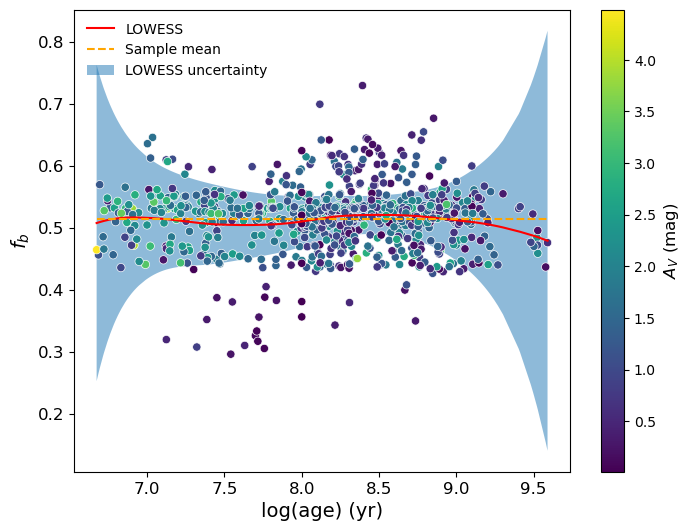

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

X = df.age.values
Y = df.bin_frac_corr.values

#AJUSTANDO O LOWESS
order = np.argsort(X)
y_sm, y_std = lowess(X,Y, f=0.3)
ax.plot(X[order], y_sm[order], color='red', label='LOWESS')
ax.hlines(Y.mean(),X.min(),X.max(),colors='orange',linestyles='--',label='Sample mean')
ax.fill_between(X[order], y_sm[order] - 1.96*y_std[order],
                 y_sm[order] + 1.96*y_std[order], alpha=0.5, label='LOWESS uncertainty')

sc = sns.scatterplot(data=df, x='age', y='bin_frac_corr', hue='Av', palette=palette, legend=False, ax=ax,)


norm = mpl.colors.Normalize(
    vmin=df['Av'].min(skipna=True),
    vmax=df['Av'].max(skipna=True)
)

cm_ = mpl.cm.ScalarMappable(norm=norm, cmap=palette)
cm_.set_array([])

cbar = fig.colorbar(cm_, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
#plt.savefig('Figures/dist_fb_age.png', bbox_inches='tight', dpi=300)
plt.show()


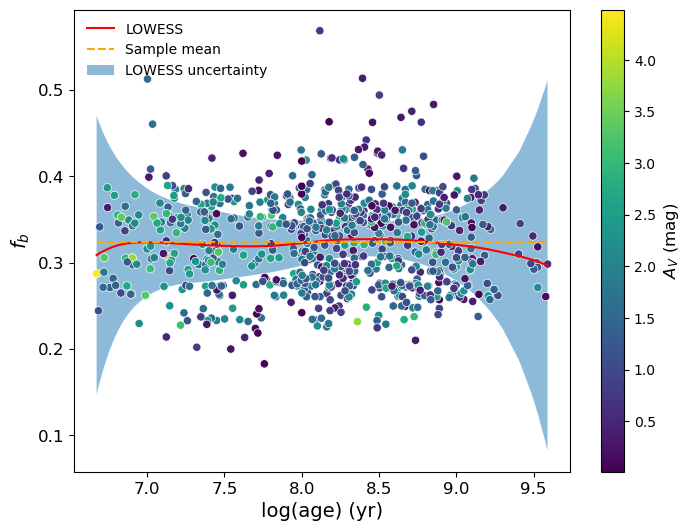

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

X = df.age.values
Y = df.bin_frac_05_corr.values

#AJUSTANDO O LOWESS
order = np.argsort(X)
y_sm, y_std = lowess(X,Y, f=0.3)
ax.plot(X[order], y_sm[order], color='red', label='LOWESS')
ax.hlines(Y.mean(),X.min(),X.max(),colors='orange',linestyles='--',label='Sample mean')
ax.fill_between(X[order], y_sm[order] - 1.96*y_std[order],
                 y_sm[order] + 1.96*y_std[order], alpha=0.5, label='LOWESS uncertainty')

sc = sns.scatterplot(data=df, x='age', y='bin_frac_05_corr', hue='Av', palette=palette, legend=False, ax=ax,)


norm = mpl.colors.Normalize(
    vmin=df['Av'].min(skipna=True),
    vmax=df['Av'].max(skipna=True)
)

cm_ = mpl.cm.ScalarMappable(norm=norm, cmap=palette)
cm_.set_array([])

cbar = fig.colorbar(cm_, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
#plt.savefig('Figures/dist_fb_age.png', bbox_inches='tight', dpi=300)
plt.show()
